# 01 | Implementation of SHAP, LIME and IEI on the ENDORISK BN

**Notebook:** In this notebook you can find the SHAP, LIME and Kyrimi et al. (2020)'s IEI implementation on the ENDORISK Bayesian Network for 'LNM' (lymph node metastasis).

This notebook serves as the code used and described in the Bachelor thesis of Juri Jansen (s1096620), a student at the Radboud University. 

The results from this notebook will be used for evaluation in the 2nd notebook, this is where all the metrics will be computed: 
fidelity, identity, separability and execution time.

Results, library versions etc will be stored in different files for reproducibility purposes. 

**Pipeline.**

1. **Setup** — imports, config, output directories
2. **Load the BN** — BIFReader("Endorisk/endomcancer.bif")
3. **Inference + cached predict_proba** — wrap Variable Elimination so SHAP and LIME can call it as a model-agnostic classifier
4. **Per-seed experiment loop** — for each base seed s ∈ {42..46}:
   - 4.1 Forward sample background pool (seed=s, N=1,000)
   - 4.2 Forward sample explained instances (seed=s+100, N=1,000)
   - 4.3 Integer-encode both pools
   - 4.4 SHAP: KernelExplainer with 100 random background samples → values for 1,000 instances
   - 4.5 LIME: LimeTabularExplainer over background → explain 1,000 instances, capture local_pred per instance
   - 4.6 Save per-seed CSVs to output/seed_{s}/


## Step 1: Setting everything up

In [1]:
import os
import sys
import time
import warnings
import importlib.metadata as _im

import numpy as np
import pandas as pd

import shap
import lime
from lime import lime_tabular

import pgmpy
from pgmpy.readwrite import BIFReader
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling

warnings.filterwarnings("ignore")

# ── Pinned library versions (venv_new, Python 3.13.13) ───────────────────────
EXPECTED_VERSIONS = {
    "numpy"      : "2.4.4",
    "pandas"     : "3.0.2",
    "shap"       : "0.51.0",
    "lime"       : "0.2.0.1",
    "pgmpy"      : "1.1.0",
    "scipy"      : "1.17.1",
    "matplotlib" : "3.10.8",
    "seaborn"    : "0.13.2",
}
# ── Experiment configuration ──────────────────────────────────────────────────
BASE_SEEDS           = [42, 43, 44, 45, 46]
N_BACKGROUND_POOL    = 1000
N_EXPLAINED          = 1000
SHAP_BACKGROUND_SIZE = 100
LIME_NUM_SAMPLES     = 1000
TARGET               = "LNM"
BIF_PATH             = "Endorisk/endomcancer.bif"
OUTPUT_DIR           = "output"

# IEI alpha-sequence (Kyrimi 2020 §4.2.2)
IEI_ALPHA_SEQUENCE = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20,
                      0.15, 0.10, 0.05, 0.01, 0.005, 0.001]

print('done')

/Users/jurijansen/Documents/Artificial Intelligence 2023-/Artificial Intelligence 25-26/Bachelor Thesis/venv_new/lib/python3.13/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


done


In [2]:
# Here the output directory is created for each seed. Here all of the information per seed will be stored.
os.makedirs(OUTPUT_DIR, exist_ok=True)
for s in BASE_SEEDS:
    os.makedirs(os.path.join(OUTPUT_DIR, f"seed_{s}"), exist_ok=True)


#print(f"Output root: {os.path.abspath(OUTPUT_DIR)}")


## Step 2 — Load the Bayesian Network

In [3]:
# Use pgmpy's BIFReader to read the file and extract the model
reader = BIFReader(BIF_PATH)
model = reader.get_model()


print(model.check_model()) # Check if all probabilities sum to 1. True = good

print(f"Nodes : {len(model.nodes())}")
print(f"Edges : {len(model.edges())}")


print(model.nodes())


True
Nodes : 18
Edges : 38
['PR', 'Platelets', 'Survival1yr', 'LVSI', 'LNM', 'CA125', 'Histology', 'p53', 'PrimaryTumor', 'Therapy', 'Survival3yr', 'L1CAM', 'MyometrialInvasion', 'ER', 'Recurrence', 'Cytology', 'Survival5yr', 'CTMRI']


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


## Step 3 — Helper functions

SHAP and LIME need a callable that returns class probabilities for an
input array. We wrap pgmpy's Variable Elimination behind a function that
matches the scikit-learn `predict_proba(X)` interface and **cache results
per evidence tuple** — without the cache, KernelExplainer would call VE
millions of times with repeated combinations and the experiment would
take hours per seed instead of minutes. -> This is the fix AI wrote for me when SHAP originally took approximately 54 seconds per instance. Now the instance VE values are stored. This way VE does not have to be called every time.


In [5]:
ve = VariableElimination(model)

# Postoperative variables — not available at time of LNM prediction (ENDORISK paper Table 1 / Fig 3)
# Only pre-operative predictors for LNM are used.
POSTOPERATIVE_VARS = {"LVSI", "MyometrialInvasion", "Therapy", "Recurrence",
                      "Survival1yr", "Survival3yr", "Survival5yr", "PrimaryTumor"}
feature_vars = [v for v in model.nodes() if v != TARGET and v not in POSTOPERATIVE_VARS]
state_names  = {cpd.variable: cpd.state_names[cpd.variable] for cpd in model.get_cpds()}



# Module-level cache: tuple-of-state-indices -> probability vector
# Predict_cache stores values 
_predict_cache: dict = {}


def predict_proba(X_arr: np.ndarray) -> np.ndarray:
    """Model-agnostic wrapper for pgmpy Variable Elimination.

    Each row of `X_arr` is a vector of integer state indices (same column
    order as `feature_vars`). Returns an (n, n_classes) array of class
    probabilities for `TARGET`.
    
    INPUT:
        X_arr: matrix of shape (n, feature_vars) containing integer feature values for all 1000 instances
            e.g. for one instance X_arr[0] = [0, 0, 0, 2, 1, 1, 0, 0, 0] with corresponding values to 
            ['PR', 'Platelets', 'CA125', 'Histology', 'p53', 'L1CAM', 'ER', 'Cytology', 'CTMRI']
    OUTPUT: 
        results: array of all the results, with shape (n, feature_vars)
    
    """
    
    n_classes = len(state_names[TARGET])
    results = []
    
    
    # For loop to compute VE for all instances
    for instance in X_arr:
        
        # Set up the key - this will be used to check whether a specific combination of values has already been calculated. 
        key = tuple(int(round(v)) for v in instance)
        if key not in _predict_cache:
            evidence = {}
            
            for i, var in enumerate(feature_vars): 
                # Get the encoded value for this variable in the current instance
                idx = int(instance[i])
                evidence[var] = state_names[var][idx]
                
            # Run VE on the specific instance    
            r = ve.query([TARGET], evidence=evidence, show_progress=False)
            probs = r.values
            
            # Check whether a specific probability is nan
            if np.any(np.isnan(probs)):
                probs = np.ones(n_classes) / n_classes
                
            # Store the value in _predict_cache -> if the same combination occurs again, full computation is not needed.
            _predict_cache[key] = probs
        results.append(_predict_cache[key])
    return np.array(results)



def encode_samples(samples_df: pd.DataFrame) -> np.ndarray:
    """
    This function maps categorical state strings to ordinal integer values. This is needed because SHAP, LIME and IEI have no idea what to do with string values
    corresponding to the df. Row order is also maintained. 
    
    Each feature's states are mapped in the order of state_names[var] -> ['PR', 'Platelets', 'CA125', 'Histology', 'p53', 'L1CAM', 'ER', 'Cytology', 'CTMRI']
    
    INPUT:
        samples_df: pd.DataFrame containing all of the samples with their corresponding values
        e.g. for one instance:
            PR='positive', Platelets='lt_400', CA125='lt_35', Histology='grade_3', p53='mutant', L1CAM='positive', ER='positive', Cytology='no', CTMRI='no'
    OUTPUT: 
        output: X.values.astype(int)
            This is the list in the same order, but with numerical values corresponding to the features
            e.g. X_arr[0] = [0, 0, 0, 2, 1, 1, 0, 0, 0]
    
    """
    X = samples_df[feature_vars].copy()
    for var in feature_vars:
        X[var] = X[var].map({s: i for i, s in enumerate(state_names[var])})
    return X.values.astype(int)


print(f"Features ({len(feature_vars)}): {feature_vars}")
print(f"Target classes : {state_names[TARGET]}")

print("Node states (index order = integer encoding used by encode_samples):")
for var in feature_vars:
    states = model.get_cpds(var).state_names[var]
    print(f"  {var:20s} ({len(states)}) : {states}")    

# D-connection check for IEI: a feature d-separated from TARGET given all other
# observed features cannot shift the posterior when removed — impact is exactly 0.
# Computed once from graph structure; values don't matter for d-separation.
_iei_d_connected = []
for _i, _feat in enumerate(feature_vars):
    _other = [feature_vars[_j] for _j in range(len(feature_vars)) if _j != _i]
    _reachable = model.active_trail_nodes([_feat], observed=_other)
    _iei_d_connected.append(TARGET in _reachable[_feat])

print("\nD-connection to LNM (leave-one-out observed set):")
for _feat, _conn in zip(feature_vars, _iei_d_connected):
    print(f"  {_feat:<12}  {'d-connected' if _conn else 'd-SEPARATED  (impact forced to 0)'}")

Features (9): ['PR', 'Platelets', 'CA125', 'Histology', 'p53', 'L1CAM', 'ER', 'Cytology', 'CTMRI']
Target classes : ['no', 'yes']
Node states (index order = integer encoding used by encode_samples):
  PR                   (2) : ['positive', 'negative']
  Platelets            (2) : ['lt_400', 'ge_400']
  CA125                (2) : ['lt_35', 'ge_35']
  Histology            (3) : ['grade_1', 'grade_2', 'grade_3']
  p53                  (2) : ['wildtype', 'mutant']
  L1CAM                (2) : ['negative', 'positive']
  ER                   (2) : ['positive', 'negative']
  Cytology             (2) : ['no', 'yes']
  CTMRI                (2) : ['no', 'yes']

D-connection to LNM (leave-one-out observed set):
  PR            d-connected
  Platelets     d-connected
  CA125         d-connected
  Histology     d-connected
  p53           d-connected
  L1CAM         d-connected
  ER            d-connected
  Cytology      d-connected
  CTMRI         d-connected


### IEI — Incremental Explanation of Inference

The IEI method proposed by Kyrimi et al. (2020) explains BN inference by
measuring, for each evidence variable $e_i$, how much the target distribution
$P(T \mid E)$ shifts when $e_i$ is temporarily removed from the evidence set.

**Implementation: Level 1** — per-feature impact as a Hellinger distance.

Kyrimi et al. (2020) describe the impact of an evidence variable $E_i=e_i$ relates to the distance between the posterior porbability with all the evidence $P(T|E)$ and the marginal posterior probability when $e_i$ is excluded from the set of evidence $P(T|E\e_i)$. Which we ddenote as:

Per-feature (leave-one-out) impact (Eq. 1):

$$
\mathrm{Im}_E(e_i) = D_H\!\left(\, P(T \mid E)\ \big\|\ P(T \mid E \setminus \{e_i\}) \,\right).
$$

All exact mathematical formulas used in this notebook can be found in Kyrimi et al. (2020)s paper. 

**Reference:**
Kyrimi, E., Mossadegh, S., Tai, N., & Marsh, W. (2020). An incremental
explanation of inference in Bayesian networks for increasing model
trustworthiness and supporting clinical decision making.
*Artificial Intelligence in Medicine*, 103, 101812.
https://doi.org/10.1016/j.artmed.2020.101812


In [6]:
# IEI helper cache (leave-one-out VE queries — separate cache from _predict_cache)
# Impact scores are always >= 0 (Hellinger distance) — a fundamental difference from
# SHAP (can be negative) and LIME (can be negative).
_iei_cache: dict = {}


# 

def hellinger_distance(p: np.ndarray, q: np.ndarray) -> float:
    """Hellinger distance between two discrete distributions (Kyrimi 2020).
    
    Follows the formula 1:1
    D_H(P, Q) = (1/sqrt(2)) * sqrt(sum_i (sqrt(p_i) - sqrt(q_i))^2)
    
    Range [0, 1]: 0 = identical, 1 = maximally different.
    
    INPUTS:
        p : np.ndarray
            First probability distribution over target states,
            e.g. P(LNM | all evidence) = [0.869, 0.131]
        q : np.ndarray
            Second probability distribution over target states,
            e.g. P(LNM | evidence minus one feature) = [0.712, 0.288]
        
    OUTPUT:
        distance: Hellinger distance computed from p and q in range [0, 1]
    
    
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    
    distance = float(np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)) / np.sqrt(2))
    return distance




def ve_leave_one_out(row_enc: np.ndarray, exclude_idx: int) -> np.ndarray:
    """
    Function that computes the probability distribution (using VE) excluding evidence from the feature located at exclude_idx.
    
    The output is also stored in _iei_cache_key to save computation in the future -> variable combinations are only calculated once, 
        the same combination is not calculated multiple times, when the output remains the same ->
    
    This can be done because the Variable Elimination algorithm is deterministic, it will always output the same with identical inputs. 
    
    
    INPUT: 
        row_enc: values for all features of a single instance
            e.g. [0, 0, 0, 2, 1, 1, 0, 0, 0]       
        exclude_idx: index of the feature that should be overlooked from the evidence.
    
    OUTPUT:
        _iei_cache[key]: the probability of LNM with the evidence excluding 'exclude_idx'. 
            i.e. P(LNM | evidence \ exclude_idx)

    Uses a separate cache keyed on (row_enc with -1 at exclude_idx).
    Returns probability vector over TARGET states.
    """
    key = tuple(-1 if j == exclude_idx else int(row_enc[j])
                for j in range(len(feature_vars)))
    if key not in _iei_cache:
        evidence = {}
        for j, var in enumerate(feature_vars):
            if j == exclude_idx:
                continue
            idx = max(0, min(int(row_enc[j]), len(state_names[var]) - 1))
            evidence[var] = state_names[var][idx]
        r = ve.query([TARGET], evidence=evidence, show_progress=False)
        probs = r.values
        if np.any(np.isnan(probs)):
            probs = np.ones(len(state_names[TARGET])) / len(state_names[TARGET])
        _iei_cache[key] = probs
    return _iei_cache[key]





def _compute_alpha_threshold(p_full: np.ndarray, p_prior: np.ndarray, impacts: np.ndarray) -> tuple:
    """Automatic significance threshold via the α-sequence (Kyrimi 2020, Section 4.2.2).

    Returns (alpha_selected, theta, list_of_significant_feature_indices).
    """
    
    # Alpha sequence described by Kyrimi et al. (2020)
    alpha_sequence = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.01, 0.005, 0.001]
    
    # At least n/2 features should be above significane threshold
    n_features = len(impacts)
    half = n_features / 2

    for alpha in alpha_sequence:
        # from Kyrimi: 
        # "a parameter alpha, defining G as a proportion of the difference between P(T|E) and P(T): G = P(T|E) - \alpha(P(T|E) - P(T))" [Eq. 6]
        
        G = p_full - alpha * (p_full - p_prior) # 
        
        G = np.clip(G, 0, None)
        G_sum = G.sum()
        if G_sum > 0:
            G = G / G_sum
            
        # "For each G, a threshold is calculated, such as theta = D_h(P(T|E), G)." -> Kyrimi et al. (2020)
        theta = hellinger_distance(p_full, G)
        
        
        
        # A variable is significant if it is >= threshold. 
        E_sig = [i for i, impact in enumerate(impacts) if impact >= theta]
        
        # Starting with the largest αi, each smaller value is tested until at least half of the evidence variables are included in Esig.
        if len(E_sig) >= half:
            return alpha, theta, E_sig

    # If no alpha can be found, this fallback will happen.
    # Use smallest alpha (nearly always gives non-empty E_sig)
    alpha = 0.001
    G = p_full - alpha * (p_full - p_prior)
    G = np.clip(G, 0, None)
    G_sum = G.sum()
    if G_sum > 0:
        G = G / G_sum
    theta = hellinger_distance(p_full, G)
    E_sig = [i for i, imp in enumerate(impacts) if imp >= theta]
    return alpha, theta, E_sig


def _conflict_category(row_enc: np.ndarray, p_full: np.ndarray,
                        p_prior: np.ndarray, exclude_idx: int,
                        im_E: float) -> str:
    """
    Classifies one evidence variable as Dominant, Consistent, Conflicting, or Mixed.
    Implements Table 1 and Eq. 7-12 from Kyrimi et al. (2020), Section 4.2.3.

    The classification is based on comparing the per-state direction of change
    caused by feature 'exclude_idx' against the direction caused by all evidence together.

    INPUT:
        row_enc     : 1-D integer-encoded feature vector, e.g. [0, 0, 0, 2, 1, 1, 0, 0, 0]
        p_full      : P(T|E)  — full posterior over target states, shape (n_classes,)
        p_prior     : P(T)    — unconditional prior over target states, shape (n_classes,)
        exclude_idx : index of the feature to classify, in [0, n_features-1]
        im_E        : Im_E(E) — total evidence impact D_H(P(T|E) || P(T)), used as
                      reference to distinguish Dominant from Consistent (Table 1)

    OUTPUT:
        str — one of: "dominant", "consistent", "conflicting",
                      "mixed_consistent", "mixed_conflicting"
    """

    # Run leave-one-out VE to get P(T| Evidence / e_i) 
    p_minus = ve_leave_one_out(row_enc, exclude_idx)

    # Impact of this single feature: how much does P(T|E) shift when e_i is removed?
    # Used to distinguish Dominant from Consistent (Table 1: Im_E(e_i) > Im_E(E))
    im_ei = hellinger_distance(p_full, p_minus)

    # ── Eq. 7: per-state shift caused by feature e_i ─────────────────────────────────
    # δ_tl(e_i) = P(t_l|E) - P(t_l|E \ {e_i})
    delta_ei = p_full - p_minus

    # Per-state shift caused by all evidence together
    # δ_tl(E) = P(t_l|E) - P(t_l)
    delta_E = p_full - p_prior

    # ── Eq. 8-9: compare sign of δ_tl(e_i) vs δ_tl(E) per target state ──────────────
    # States where both shifts are near zero are ignored (tol filter),
    # since a sign comparison on near-zero values is numerically meaningless.
    tol = 1e-10
    consistent_states  = [np.sign(delta_ei[l]) == np.sign(delta_E[l])   # Eq. 8
                          for l in range(len(p_full))
                          if abs(delta_ei[l]) > tol and abs(delta_E[l]) > tol]
    conflicting_states = [np.sign(delta_ei[l]) != np.sign(delta_E[l])   # Eq. 9
                          for l in range(len(p_full))
                          if abs(delta_ei[l]) > tol and abs(delta_E[l]) > tol]

    # Edge case: all per-state differences are near zero → feature has no directional
    # effect, treat as consistent (not specified by paper, safe default)
    if not consistent_states and not conflicting_states:
        return "consistent"

    # ── Eq. 10-11: check if ALL states agree on the same direction ────────────────────
    # D_consistent(e_i) = ∀ t_l . d_consistent(e_i, t_l)   [Eq. 10]
    # D_conflicting(e_i) = ∀ t_l . d_conflicting(e_i, t_l) [Eq. 11]
    all_consistent  = all(consistent_states)  and len(consistent_states)  > 0
    all_conflicting = all(conflicting_states) and len(conflicting_states) > 0

    if all_consistent:
        # Table 1: Dominant if Im_E(e_i) > Im_E(E), Consistent otherwise.
        # "It is possible that removing e_i leads to a greater impact than Im_E(E),
        #  even though the direction is consistent. This suggests that e_i dominates
        #  the remaining evidence." — Kyrimi et al. (2020), §4.2.3
        return "dominant" if im_ei > im_E else "consistent"

    if all_conflicting:
        # Table 1: feature pushes P(T|E) against the direction of the overall evidence
        return "conflicting"

    # ── Eq. 12: Mixed — not all states agree on the same direction ───────────────────
    # D_mixed(e_i) = ¬D_consistent(e_i) ∧ ¬D_conflicting(e_i)   [Eq. 12]
    # Resolve by comparing the Hellinger contribution of the consistent-direction states
    # against the conflicting-direction states (Table 1, bottom two rows).
    # Note: for a binary target (LNM), Mixed is structurally unreachable because
    # the two states always shift in opposite directions simultaneously.
    consistent_mask  = np.array([np.sign(delta_ei[l]) == np.sign(delta_E[l])
                                 for l in range(len(p_full))], dtype=bool)
    conflicting_mask = ~consistent_mask

    def partial_hellinger(mask):
        # Restrict both distributions to the masked states, renormalise, then
        # compute Hellinger distance on those states only
        p_ = np.where(mask, p_full,  0.0)
        q_ = np.where(mask, p_minus, 0.0)
        s_p = p_.sum(); s_q = q_.sum()
        if s_p < 1e-12 and s_q < 1e-12:
            return 0.0
        if s_p > 0: p_ = p_ / s_p
        if s_q > 0: q_ = q_ / s_q
        return hellinger_distance(p_, q_)

    h_consistent  = partial_hellinger(consistent_mask)
    h_conflicting = partial_hellinger(conflicting_mask)

    # Table 1: whichever side has the larger partial Hellinger contribution dominates
    return "mixed_consistent" if h_consistent >= h_conflicting else "mixed_conflicting"



# Main function for IEI
def explain_iei(row_enc: np.ndarray, p_full: np.ndarray, p_prior: np.ndarray) -> dict:
    """
    Computes the full Kyrimi et al. (2020) level 1 IEI implementation. 
    
    A single instance is computed here. 

    INPUT:
        row_enc:  1-D integer-encoded feature vector (length = len(feature_vars))
            e.g. [0, 0, 0, 2, 1, 1, 0, 0, 0]    
        p_full:   P(T|E) — posterior with all evidence (shape: n_classes) -> probability of LNM given evidence = row_enc 
        p_prior:  P(T)   — unconditional prior (shape: n_classes)

    OUTPUT:
        Returns dict with keys:
            'impacts'     : np.ndarray shape (n_features,) — Hellinger distances
            'im_E'        : float — total evidence impact D_H(P(T|E) ‖ P(T))
            'alpha'       : float — selected α
            'theta'       : float — significance threshold
            'e_sig'       : list[int] — indices of significant features
            'conflict'    : list[str] — conflict category per feature (all features)
    """
    
    
    # ===================================================================================
    # STEP 1: Compute leave-one-out Hellinger distances
    # ===================================================================================
    # For each feature, we temporarily remove it from the evidence and re-run VE.
    
    # The Hellinger distance between the full posterior (P(LNM | Evidence) and the leave-one-out posterior (P(LNM | Evidence / feature[i])
    # Tells us how much feature[i] contibutes to the prediction. -> A high distance means the feature has a large impact on P(LNM | Evidence)
    
    n = len(feature_vars)
    
    
    # Initialize 1D array that will store the leave-one-out Hellinger distance per feature. 
    impacts = np.zeros(n)

    # Use the ve_leave_one_out to compute the probabilities for leave one out and compute the hellinger distance based on this.
    # D-separated features cannot shift the posterior — skip VE and assign impact 0.
    for i in range(n):
        if not _iei_d_connected[i]:
            impacts[i] = 0.0
            continue
        p_minus  = ve_leave_one_out(row_enc, i)
        impacts[i] = hellinger_distance(p_full, p_minus)
    
    
    
    # ===================================================================================
    # STEP 2; Total evidence impact and significance threshold
    # ====================================================================================
    

    # im_E measures how much the full evidence set Evidence shifts P(LNM) toward P(LNM | Evidence).
    # This is used as a reference magnitude in the conflict categorisation step.
    
    im_E = hellinger_distance(p_full, p_prior)
    
    
    # Find the significance threshold (theta) via the alpha-sequence (Kyrimi 2020, 4.2.2).
    
    # The alpha-sequence starts from alpha=0.5 and decreases it until at least n/2 features exceed theta.
    # Returns the selected threshold (theta), the chosen alpha value, and the indices of the significant features (E_sig).

    alpha, theta, e_sig = _compute_alpha_threshold(p_full, p_prior, impacts)

    # ===================================================================================
    # STEP 3: Conflict analysis
    # ===================================================================================
    # Kyrimi et al. (2020): " When we perform a conflict analysis we compare 
    #(i) the direction of the change and 
    #(ii) the impact on the target when each evidence variable is removed with the impact when all the evidence variables are removed. "
    
    
    conflict = [
        _conflict_category(row_enc, p_full, p_prior, i, im_E)
        for i in range(n)
    ]

    return {
        "impacts" : impacts,
        "im_E"    : im_E,
        "alpha"   : alpha,
        "theta"   : theta,
        "e_sig"   : e_sig,
        "conflict": conflict,
    }

print('IEI Functions loaded')

IEI Functions loaded


## Step 4 — Per-seed experiment loop

For each seed these steps are taken:

| Sub-step | What happens |
|----------|--------------|
| 4.1 | Forward-sample 1,000 instances with `seed=s` → background pool |
| 4.2 | Forward-sample 1,000 instances with `seed=s+100` → explained set |
| 4.3 | Integer-encode both pools; pre-warm cache on explained set |
| 4.4 | Run SHAP `KernelExplainer` (100 background samples) on the explained set |
| 4.5 | Run LIME on each instance, capturing weights and `local_pred` |
| 4.6 | Run IEI level 1 on each instance |
| 4.7 | Persist all artefacts to `output/seed_{s}/` |

The inference cache `_predict_cache` is **shared across seeds** within
this notebook session — this only helps later seeds when their forward
samples repeat evidence tuples seen earlier (likely, given the BN
concentrates probability mass).


In [7]:
sampler = BayesianModelSampling(model)
results_by_seed: dict = {}


# Run the whole pipeline for each seed
for s in BASE_SEEDS:
    print(f"\n{'='*72}")
    print(f"SEED {s}")
    print(f"{'='*72}")
    seed_dir = os.path.join(OUTPUT_DIR, f"seed_{s}")

    #========= 4.1 / 4.2  Forward sample two pools ===================================
    #=================================================================================
    # (1) Background pool: used by SHAP and LIME as a reference distribution.
    # (2) Explained set: the 1000 instances we actually explain.
    # Different seeds ensure background and explained instances are independent.
    print(f"[4.1] background pool  : forward_sample(seed={s}, size={N_BACKGROUND_POOL})")
    bg_samples = sampler.forward_sample(size=N_BACKGROUND_POOL, seed=s, show_progress=False)

    print(f"[4.2] explained set    : forward_sample(seed={s+100}, size={N_EXPLAINED})")
    ex_samples = sampler.forward_sample(size=N_EXPLAINED, seed=s+100, show_progress=False) # s + 100 ensures a different seed than bg_samples

    #========= 4.3 Encode + Pre warm cache ===========================================
    #=================================================================================
    # Convert state strings to integer indices so SHAP, LIME and IEI
    # can work with numerical arrays instead of strings.
    # Change to float because SHAP and LIME expect float input.

    X_bg = encode_samples(bg_samples).astype(float)
    X_ex = encode_samples(ex_samples).astype(float)
    print(f"[4.3] encoded shapes   : background {X_bg.shape}, explained {X_ex.shape}")

    
    
    # Pre-warm _predict_cache by running VE on all explained instances upfront.
    # This means every subsequent call to predict_proba during SHAP, LIME and IEI
    # will hit the cache instead of re-running VE.
    
    # Otherwise the cache ma
    print(f"      pre-warming inference cache on explained set ...")
    pred_probs_ex = predict_proba(X_ex)[:, 1]   # P(LNM=yes) per instance
    print(f"      cache size after warm-up: {len(_predict_cache):,} entries")

    #========= 4.4 SHAP ==============================================================
    #=================================================================================
    # KernelExplainer is the model-agnostic SHAP variant. It treats predict_proba as a black-box function. 
    # The background sample approximates the marginal distribution used to integrate out absent features.
    
    print(f"[4.4] SHAP KernelExplainer  background={SHAP_BACKGROUND_SIZE} samples  "
          f"({N_EXPLAINED} instances)")
    background = shap.sample(X_bg, SHAP_BACKGROUND_SIZE, random_state=s)
    explainer  = shap.KernelExplainer(predict_proba, background)

    
    
    # Compute SHAP values for all 1000 instances in one batched call.
    # l1_reg=0 disables feature selection so all 9 features always get a value.
    
    # Computing the batch is timed, and divided by N_EXPLAINED for per instance mean.
    t0 = time.perf_counter()
    shap_values = explainer.shap_values(X_ex, l1_reg=0)
    shap_total_s = time.perf_counter() - t0
    base_value = float(explainer.expected_value[1])
    print(f"      SHAP done in {shap_total_s:.1f}s  ({shap_total_s/N_EXPLAINED:.3f}s/instance)")
    print(f"      shap_values shape: {shap_values.shape}  base_value={base_value:.4f}")

    # Save SHAP values — index [:, :, 1] selects the LNM=yes class
    df_shap = pd.DataFrame(shap_values[:, :, 1], columns=feature_vars)
    df_shap.insert(0, "instance_id", range(N_EXPLAINED))
    df_shap.insert(1, "P_LNM_yes", [round(float(p), 6) for p in pred_probs_ex])
    df_shap.set_index("instance_id", inplace=True)
    df_shap.to_csv(os.path.join(seed_dir, "shap_values.csv"))

    # Save the base value separately. This is needed to reconstruct the full SHAP prediction
    pd.DataFrame({"base_value_LNM_yes": [base_value]}).to_csv(
        os.path.join(seed_dir, "shap_base_value.csv"), index=False
    )

    #========= 4.5 LIME ==============================================================
    #=================================================================================
    # LimeTabularExplainer fits a local linear surrogate around each instance. 
    # categorical_features tells LIME to perturb by sampling from training data rather than adding Gaussian noise, which is correct for discrete BN variables.
    print(f"[4.5] LIME  explaining {N_EXPLAINED} instances, num_samples={LIME_NUM_SAMPLES}")
    lime_explainer = lime_tabular.LimeTabularExplainer(
        training_data       = X_bg,
        feature_names       = feature_vars,
        class_names         = state_names[TARGET],
        categorical_features= list(range(len(feature_vars))),
        categorical_names   = {i: state_names[var] for i, var in enumerate(feature_vars)},
        mode                = "classification",
        random_state        = s,
    )

    lime_weights    = []# local linear weights per instance, shape (N, n_features)
    lime_local_pred = []# LIME's local surrogate prediction per instance
    lime_times      = []# per-instance compute time

    # Run LIME instance-per-instance
    for i in range(N_EXPLAINED):
        t0 = time.perf_counter()
        exp = lime_explainer.explain_instance(
            data_row     = X_ex[i],
            predict_fn   = predict_proba,
            num_features = len(feature_vars),     # return weights for all 9 features
            labels       = [1],                   # explain the LNM=yes class
            num_samples  = LIME_NUM_SAMPLES,
        )
        lime_times.append(time.perf_counter() - t0)

        weights = np.zeros(len(feature_vars))
        for feat_idx, w in exp.as_map()[1]:
            weights[feat_idx] = w
        lime_weights.append(weights)
        
        # local_pred is the surrogate model's prediction at this instance
        lp = float(np.asarray(exp.local_pred).ravel()[0])
        lime_local_pred.append(lp)

        if (i + 1) % 100 == 0:
            print(f"      {i+1:>4}/{N_EXPLAINED}  avg {np.mean(lime_times):.3f}s/instance  "
                  f"cache={len(_predict_cache):,}")

    lime_weights_arr    = np.array(lime_weights)
    lime_local_pred_arr = np.array(lime_local_pred)

    lime_total_s = float(sum(lime_times))
    print(f"      LIME done in {lime_total_s:.1f}s  ({np.mean(lime_times):.3f}s/instance)")

    df_lime = pd.DataFrame(lime_weights_arr, columns=feature_vars)
    df_lime.insert(0, "instance_id", range(N_EXPLAINED))
    df_lime.insert(1, "P_LNM_yes",   [round(float(p), 6) for p in pred_probs_ex])
    df_lime.insert(2, "local_pred",  [round(float(p), 6) for p in lime_local_pred_arr])
    df_lime.set_index("instance_id", inplace=True)
    df_lime.to_csv(os.path.join(seed_dir, "lime_weights.csv"))


    #========= 4.6 IEI ===============================================================
    #=================================================================================
    # IEI (Kyrimi et al., 2020) explains each instance via leave-one-out Variable Elimination. 
    # For each of the 9 features, VE is ran with that feature removed
    # the Hellinger distance (D_h) to the full posterior is the feature's impact score.
    print(f"[4.6] IEI  explaining {N_EXPLAINED} instances "
          f"({len(feature_vars)} leave-one-out VE queries each)")

    # Compute prior P(T) once per seed — no evidence conditioning
    p_prior = ve.query([TARGET], evidence={}, show_progress=False).values

    iei_impacts_list  = []
    iei_meta_list     = []
    iei_times         = []

    for i in range(N_EXPLAINED):
        # p_full is already in _predict_cache from the pre-warm step
        p_full_full = predict_proba(X_ex[i:i+1])[0]  # (n_classes,)

        t0  = time.perf_counter()
        res = explain_iei(X_ex[i], p_full_full, p_prior)
        iei_times.append(time.perf_counter() - t0)

        iei_impacts_list.append(res["impacts"])
        iei_meta_list.append({
            "instance_id" : i,
            "P_LNM_yes"   : round(float(p_full_full[1]), 6),
            "im_E"        : round(res["im_E"],   6),
            "alpha"       : round(res["alpha"],  4),
            "theta"       : round(res["theta"],  6),
            "n_e_sig"     : len(res["e_sig"]),
            "e_sig_names" : "|".join(feature_vars[k] for k in res["e_sig"]),
            "conflict_str": "|".join(res["conflict"]),
        })

        if (i + 1) % 100 == 0:
            print(f"      {i+1:>4}/{N_EXPLAINED}  "
                  f"avg {np.mean(iei_times):.4f}s/instance  "
                  f"iei_cache={len(_iei_cache):,}")

    iei_total_s = float(sum(iei_times))
    print(f"      IEI done in {iei_total_s:.1f}s  "
          f"({np.mean(iei_times):.4f}s/instance)  "
          f"iei_cache={len(_iei_cache):,}")

    # ── Save iei_impacts.csv (same layout as shap_values.csv)
    df_iei = pd.DataFrame(np.array(iei_impacts_list), columns=feature_vars)
    df_iei.insert(0, "instance_id", range(N_EXPLAINED))
    df_iei.insert(1, "P_LNM_yes",
                  [round(float(predict_proba(X_ex[i:i+1])[0][1]), 6)
                   for i in range(N_EXPLAINED)])
    df_iei.set_index("instance_id", inplace=True)
    df_iei.to_csv(os.path.join(seed_dir, "iei_impacts.csv"))

    # ── Save iei_meta.csv (threshold + conflict info per instance)
    df_iei_meta = pd.DataFrame(iei_meta_list).set_index("instance_id")
    df_iei_meta.to_csv(os.path.join(seed_dir, "iei_meta.csv"))


    #========= 4.7 X_enc + timing ====================================================
    #=================================================================================
    df_xenc = pd.DataFrame(X_ex.astype(int), columns=feature_vars)
    df_xenc.insert(0, "instance_id", range(N_EXPLAINED))
    df_xenc.set_index("instance_id", inplace=True)
    df_xenc.to_csv(os.path.join(seed_dir, "x_enc_explained.csv"))

    df_timing = pd.DataFrame({
        "method"              : ["SHAP", "LIME", "IEI"],
        "n_instances"         : [N_EXPLAINED, N_EXPLAINED, N_EXPLAINED],
        "total_time_s"        : [round(shap_total_s, 3),
                                 round(lime_total_s, 3),
                                 round(iei_total_s,  3)],
        "mean_per_instance_s" : [round(shap_total_s / N_EXPLAINED, 6),
                                 round(float(np.mean(lime_times)),  6),
                                 round(float(np.mean(iei_times)),   6)],
    })
    df_timing.to_csv(os.path.join(seed_dir, "timing.csv"), index=False)

    pd.DataFrame({
        "instance_id": range(N_EXPLAINED),
        "lime_time_s": [round(t, 6) for t in lime_times],
    }).to_csv(os.path.join(seed_dir, "lime_times_per_instance.csv"), index=False)

    results_by_seed[s] = {
        "shap_total_s"    : round(shap_total_s, 3),
        "lime_total_s"    : round(lime_total_s, 3),
        "iei_total_s"     : round(iei_total_s,  3),
        "shap_base_value" : round(base_value, 6),
        "cache_size_end"  : len(_predict_cache),
        "iei_cache_size"  : len(_iei_cache),
    }
    print(f"[4.8] saved -> {seed_dir}/")

print(f"\n{'='*72}\nAll {len(BASE_SEEDS)} seeds completed.\n{'='*72}")


SEED 42
[4.1] background pool  : forward_sample(seed=42, size=1000)
[4.2] explained set    : forward_sample(seed=142, size=1000)
[4.3] encoded shapes   : background (1000, 9), explained (1000, 9)
      pre-warming inference cache on explained set ...
      cache size after warm-up: 115 entries
[4.4] SHAP KernelExplainer  background=100 samples  (1000 instances)


  0%|          | 0/1000 [00:00<?, ?it/s]

      SHAP done in 317.8s  (0.318s/instance)
      shap_values shape: (1000, 9, 2)  base_value=0.0753
[4.5] LIME  explaining 1000 instances, num_samples=1000
       100/1000  avg 0.008s/instance  cache=744
       200/1000  avg 0.008s/instance  cache=744
       300/1000  avg 0.008s/instance  cache=744
       400/1000  avg 0.008s/instance  cache=744
       500/1000  avg 0.008s/instance  cache=744
       600/1000  avg 0.008s/instance  cache=744
       700/1000  avg 0.008s/instance  cache=744
       800/1000  avg 0.008s/instance  cache=744
       900/1000  avg 0.008s/instance  cache=744
      1000/1000  avg 0.008s/instance  cache=744
      LIME done in 8.4s  (0.008s/instance)
[4.6] IEI  explaining 1000 instances (9 leave-one-out VE queries each)
       100/1000  avg 0.0017s/instance  iei_cache=264
       200/1000  avg 0.0013s/instance  iei_cache=389
       300/1000  avg 0.0011s/instance  iei_cache=465
       400/1000  avg 0.0010s/instance  iei_cache=526
       500/1000  avg 0.0010s/instanc

  0%|          | 0/1000 [00:00<?, ?it/s]

      SHAP done in 163.6s  (0.164s/instance)
      shap_values shape: (1000, 9, 2)  base_value=0.0989
[4.5] LIME  explaining 1000 instances, num_samples=1000
       100/1000  avg 0.008s/instance  cache=768
       200/1000  avg 0.008s/instance  cache=768
       300/1000  avg 0.008s/instance  cache=768
       400/1000  avg 0.008s/instance  cache=768
       500/1000  avg 0.008s/instance  cache=768
       600/1000  avg 0.008s/instance  cache=768
       700/1000  avg 0.008s/instance  cache=768
       800/1000  avg 0.008s/instance  cache=768
       900/1000  avg 0.008s/instance  cache=768
      1000/1000  avg 0.008s/instance  cache=768
      LIME done in 8.0s  (0.008s/instance)
[4.6] IEI  explaining 1000 instances (9 leave-one-out VE queries each)
       100/1000  avg 0.0003s/instance  iei_cache=798
       200/1000  avg 0.0004s/instance  iei_cache=840
       300/1000  avg 0.0004s/instance  iei_cache=868
       400/1000  avg 0.0004s/instance  iei_cache=880
       500/1000  avg 0.0004s/instanc

...

      SHAP done in 314.5s  (0.314s/instance)
      shap_values shape: (1000, 9, 2)  base_value=0.0866
[4.5] LIME  explaining 1000 instances, num_samples=1000
       100/1000  avg 0.008s/instance  cache=768
       200/1000  avg 0.008s/instance  cache=768
       300/1000  avg 0.008s/instance  cache=768
       400/1000  avg 0.008s/instance  cache=768
       500/1000  avg 0.008s/instance  cache=768
       600/1000  avg 0.008s/instance  cache=768
       700/1000  avg 0.008s/instance  cache=768
       800/1000  avg 0.008s/instance  cache=768
       900/1000  avg 0.008s/instance  cache=768
      1000/1000  avg 0.008s/instance  cache=768
      LIME done in 7.7s  (0.008s/instance)
[4.6] IEI  explaining 1000 instances (9 leave-one-out VE queries each)
       100/1000  avg 0.0002s/instance  iei_cache=1,021
       200/1000  avg 0.0002s/instance  iei_cache=1,029
       300/1000  avg 0.0003s/instance  iei_cache=1,052
       400/1000  avg 0.0003s/instance  iei_cache=1,070
       500/1000  avg 0.0003s

  0%|          | 0/1000 [00:00<?, ?it/s]

      SHAP done in 316.0s  (0.316s/instance)
      shap_values shape: (1000, 9, 2)  base_value=0.0863
[4.5] LIME  explaining 1000 instances, num_samples=1000
       100/1000  avg 0.008s/instance  cache=768
       200/1000  avg 0.008s/instance  cache=768
       300/1000  avg 0.008s/instance  cache=768
       400/1000  avg 0.008s/instance  cache=768
       500/1000  avg 0.008s/instance  cache=768
       600/1000  avg 0.008s/instance  cache=768
       700/1000  avg 0.008s/instance  cache=768
       800/1000  avg 0.008s/instance  cache=768
       900/1000  avg 0.008s/instance  cache=768
      1000/1000  avg 0.008s/instance  cache=768
      LIME done in 7.8s  (0.008s/instance)
[4.6] IEI  explaining 1000 instances (9 leave-one-out VE queries each)
       100/1000  avg 0.0003s/instance  iei_cache=1,129
       200/1000  avg 0.0003s/instance  iei_cache=1,142
       300/1000  avg 0.0003s/instance  iei_cache=1,162
       400/1000  avg 0.0003s/instance  iei_cache=1,162
       500/1000  avg 0.0003s

  0%|          | 0/1000 [00:00<?, ?it/s]

      SHAP done in 320.4s  (0.320s/instance)
      shap_values shape: (1000, 9, 2)  base_value=0.0890
[4.5] LIME  explaining 1000 instances, num_samples=1000
       100/1000  avg 0.008s/instance  cache=768
       200/1000  avg 0.008s/instance  cache=768
       300/1000  avg 0.008s/instance  cache=768
       400/1000  avg 0.008s/instance  cache=768
       500/1000  avg 0.008s/instance  cache=768
       600/1000  avg 0.008s/instance  cache=768
       700/1000  avg 0.008s/instance  cache=768
       800/1000  avg 0.008s/instance  cache=768
       900/1000  avg 0.008s/instance  cache=768
      1000/1000  avg 0.008s/instance  cache=768
      LIME done in 7.8s  (0.008s/instance)
[4.6] IEI  explaining 1000 instances (9 leave-one-out VE queries each)
       100/1000  avg 0.0003s/instance  iei_cache=1,248
       200/1000  avg 0.0003s/instance  iei_cache=1,261
       300/1000  avg 0.0003s/instance  iei_cache=1,270
       400/1000  avg 0.0003s/instance  iei_cache=1,281
       500/1000  avg 0.0003s

## Extra code used for testing - not used for the final thesis product

### Feature correlation matrix - was only used for testing.

In this matrix I was curious on the correlation between the different features. This helps me understand outputs. 

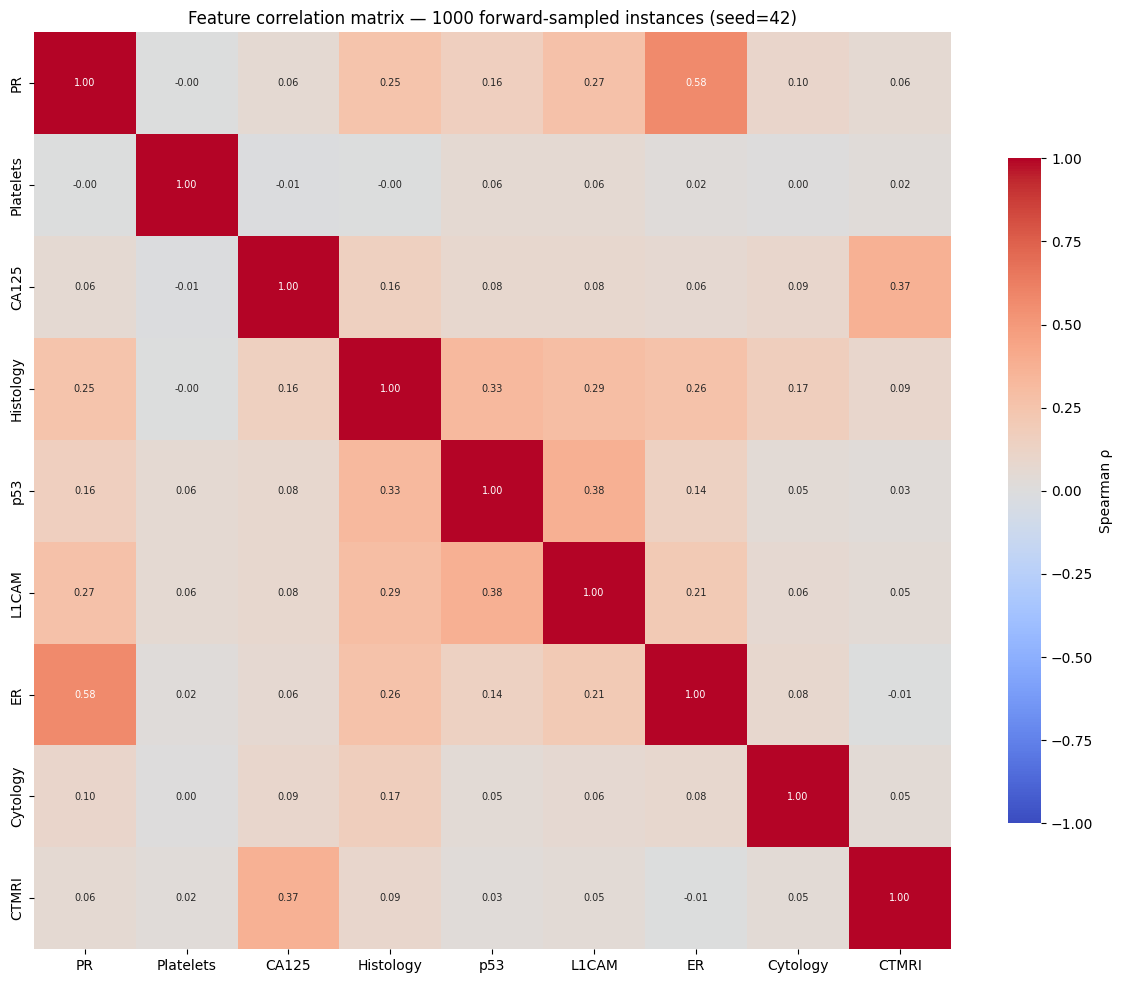

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a single fixed seed for EDA — independent of the experiment loop seeds
EDA_SEED = 42
EDA_N    = 1000

sampler     = BayesianModelSampling(model)
eda_samples = sampler.forward_sample(size=EDA_N, seed=EDA_SEED, show_progress=False)
X_eda       = encode_samples(eda_samples)              # (N, 17) integer-encoded

# Spearman handles the mix of binary + ordinal cleanly. For binary features
# Spearman == Pearson == phi; for ordinal it doesn't assume equal step sizes.
corr = pd.DataFrame(X_eda, columns=feature_vars).corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
)
plt.title(f"Feature correlation matrix — {EDA_N} forward-sampled instances (seed={EDA_SEED})")
plt.tight_layout()
plt.show()